In [2]:
!pip uninstall -y datasets
!pip install "datasets==3.6.0" hexbytes

Found existing installation: datasets 4.0.0
Uninstalling datasets-4.0.0:
  Successfully uninstalled datasets-4.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 9.9 MB/s eta 0:00:00


In [3]:
import re
import pandas as pd
import seaborn as sns
from hexbytes import HexBytes
import matplotlib.pyplot as plt
from datasets import load_dataset

# Due to a bug in the HuggingFace dataset, at the moment two file checksums do not correspond to what
# is in the dataset metadata, thus we have to load the data splits with the flag ignore_verification
# set to true
train_set = load_dataset("mwritescode/slither-audited-smart-contracts", 'big-multilabel', split='train', trust_remote_code=True)
test_set = load_dataset("mwritescode/slither-audited-smart-contracts", 'big-multilabel', split='test', trust_remote_code=True)
val_set = load_dataset("mwritescode/slither-audited-smart-contracts", 'big-multilabel', split='validation', trust_remote_code=True)

README.md: 0.00B [00:00, ?B/s]

slither-audited-smart-contracts.py: 0.00B [00:00, ?B/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

data/raw/contracts0.parquet:   0%|          | 0.00/203M [00:00<?, ?B/s]

data/raw/contracts1.parquet:   0%|          | 0.00/197M [00:00<?, ?B/s]

...

big-splits.csv: 0.00B [00:00, ?B/s]

small-splits.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/79641 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/15972 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10861 [00:00<?, ? examples/s]

In [4]:
def remove_comments(string):
    pattern = r"(\".*?\"|\'.*?\')|(/\*.*?\*/|//[^\r\n]*$)"
    # first group captures quoted strings (double or single)
    # second group captures comments (//single-line or /* multi-line */)
    regex = re.compile(pattern, re.MULTILINE|re.DOTALL)
    def _replacer(match):
        # if the 2nd group is not None, then we have captured a real comment string.
        if match.group(2) is not None:
            return ""
        else: # otherwise, we will return the 1st group
            return match.group(1)
    return regex.sub(_replacer, string)

def get_lenghts(example):
    code = remove_comments(example['source_code'])
    example['sourcecode_len'] = len(code.split())
    example['bytecode_len'] = len(HexBytes(example['bytecode']))
    return example

In [5]:
COLS_TO_REMOVE = ['source_code', 'bytecode']

LABELS = {0:'access-control', 1:'arithmetic', 2:'other', 3:'reentrancy', 4:'safe', 5:'unchecked-calls'}

datasets = []
for split in [train_set, test_set, val_set]:
    split_df = pd.DataFrame(split.map(get_lenghts, remove_columns=COLS_TO_REMOVE)).explode('slither')
    split_df['slither'] = split_df['slither'].map(LABELS)
    datasets.append(split_df)

concatenated = pd.concat([split.assign(dataset=split_name) for split, split_name in zip(datasets, ['train', 'test', 'val'])])

Map:   0%|          | 0/79641 [00:00<?, ? examples/s]

Map:   0%|          | 0/15972 [00:00<?, ? examples/s]

Map:   0%|          | 0/10861 [00:00<?, ? examples/s]

In [6]:
concatenated.head()

,address,slither,sourcecode_len,bytecode_len,dataset
0,0x006699d34AA3013605d468d2755A2Fe59A16B12B,arithmetic,973,5887,train
1,0x00c83aeCC790e8a4453e5dD3B0B4b3680501a7A7,arithmetic,10705,13263,train
1,0x00c83aeCC790e8a4453e5dD3B0B4b3680501a7A7,reentrancy,10705,13263,train
1,0x00c83aeCC790e8a4453e5dD3B0B4b3680501a7A7,other,10705,13263,train
2,0x010c5322d78c88ca18282b0a072a8913648b3038,safe,193,1683,train


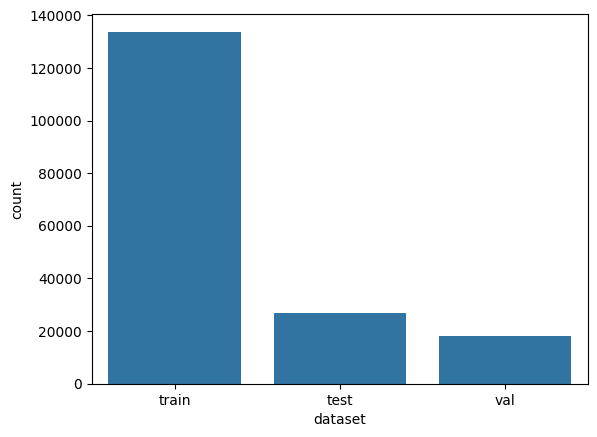

In [7]:
sns.countplot(x='dataset', data=concatenated)
plt.show()

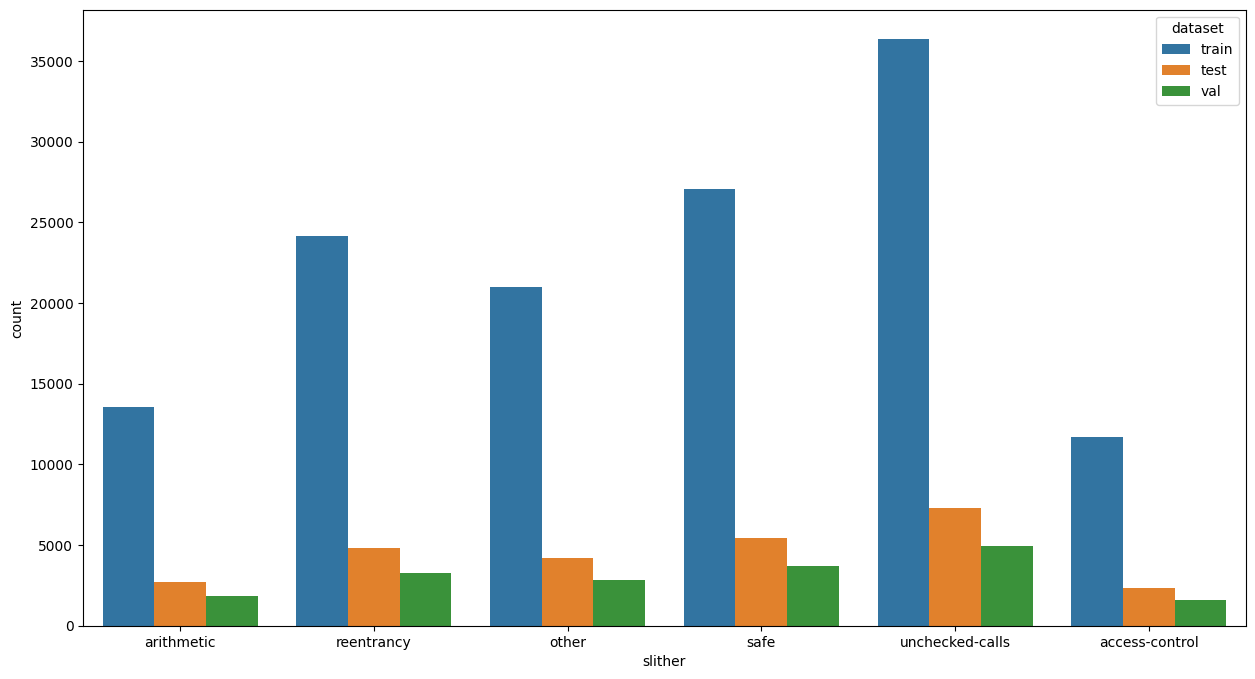

In [8]:
_, ax = plt.subplots(figsize=(15, 8))
sns.countplot(x='slither', data=concatenated, hue='dataset', ax=ax)

plt.show()

In [9]:
concatenated = concatenated.drop('slither', axis='columns')
concatenated = concatenated[~concatenated['address'].duplicated(keep='first')].reset_index()

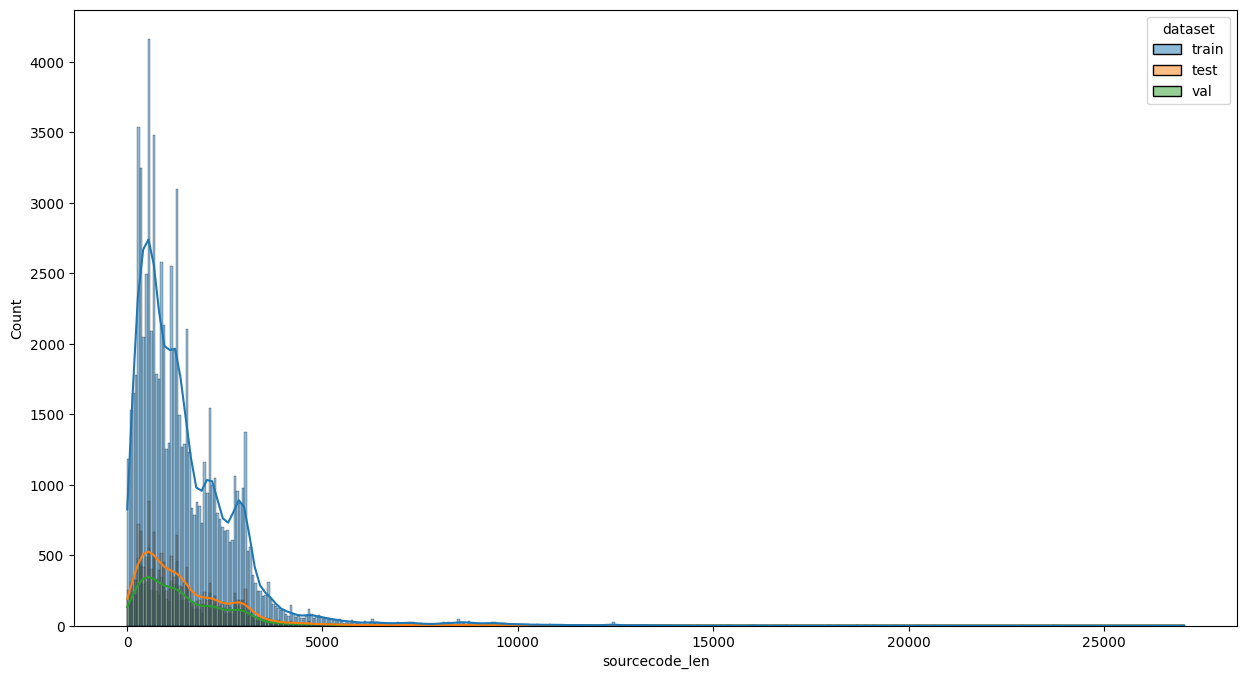

In [10]:
_, ax = plt.subplots(figsize=(15, 8))
sns.histplot(data=concatenated, x="sourcecode_len", kde=True, hue='dataset', ax=ax)
plt.show()

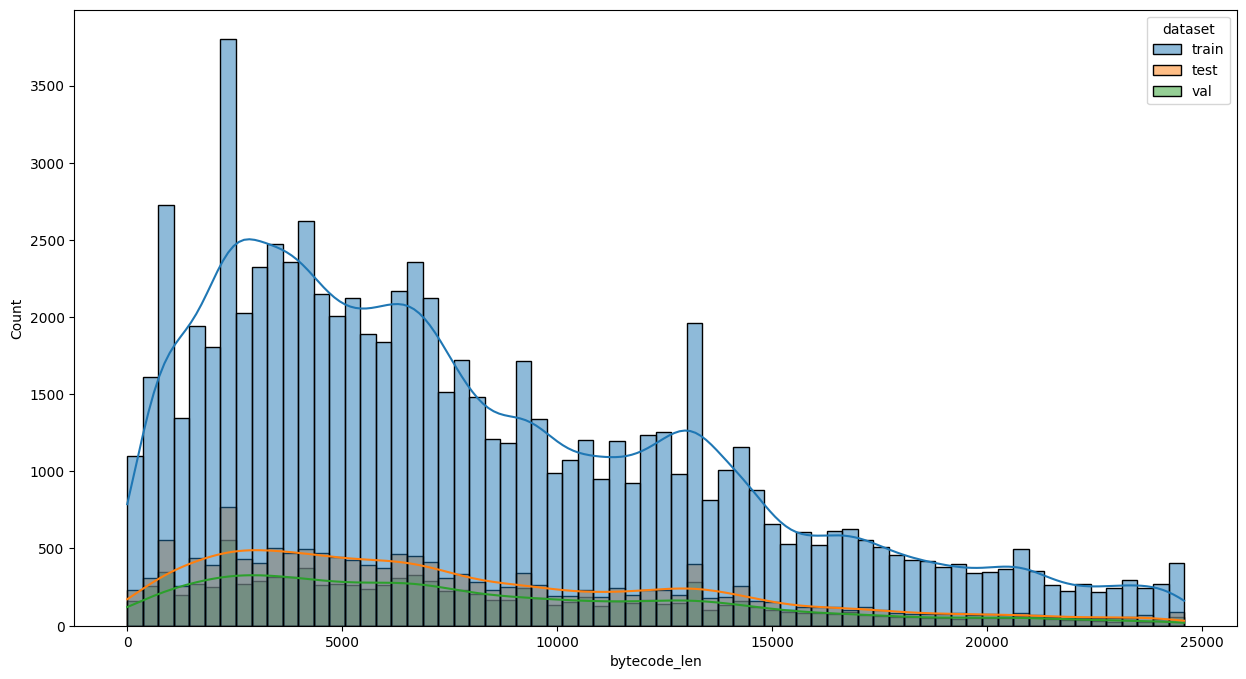

In [11]:
_, ax = plt.subplots(figsize=(15, 8))
sns.histplot(data=concatenated, x="bytecode_len", kde=True, hue='dataset', ax=ax)
plt.show()

In [12]:
empty_bytecodes = concatenated[concatenated['bytecode_len'] == 0]['dataset'].value_counts()
empty_bytecodes

,count
dataset,
train,227
test,51
val,30


In [13]:
empty_bytecodes / concatenated['dataset'].value_counts()

,count
dataset,
train,0.002850
test,0.003193
val,0.002762


# Task
Process the raw smart contract data to construct a binary vulnerability label (vulnerable/not vulnerable), retaining the raw source code and bytecode for each contract.

## Data Loading and Binary Label Construction

### Subtask:
Process the raw smart contract data to create a binary label indicating whether a contract is vulnerable or not, while retaining the raw source code and bytecode for each contract.


**Reasoning**:
First, I will define the `process_contract_data` function as specified, which will create a binary 'vulnerable' label, calculate source code and bytecode lengths, and retain other necessary information. Then, I will apply this function to the raw datasets using the `.map()` method to create processed datasets. After processing, I will convert these datasets into pandas DataFrames, concatenate them, and display the head and info to verify the new structure.



In [14]:
def process_contract_data(example):
    # Create a binary 'vulnerable' label
    # A contract is vulnerable if any of its labels is not 'safe' (which is mapped to 4)
    vulnerable = 0
    if example['slither']:
        if any(label != 4 for label in example['slither']):
            vulnerable = 1

    # Calculate sourcecode_len
    cleaned_source_code = remove_comments(example['source_code'])
    sourcecode_len = len(cleaned_source_code.split())

    # Calculate bytecode_len
    bytecode_len = len(HexBytes(example['bytecode']))

    return {
        'address': example['address'],
        'source_code': example['source_code'],
        'bytecode': example['bytecode'],
        'sourcecode_len': sourcecode_len,
        'bytecode_len': bytecode_len,
        'vulnerable': vulnerable
    }

# Apply the function to each dataset split
train_processed = train_set.map(process_contract_data)
test_processed = test_set.map(process_contract_data)
val_processed = val_set.map(process_contract_data)

# Convert processed datasets to pandas DataFrames
train_df = pd.DataFrame(train_processed)
test_df = pd.DataFrame(test_processed)
val_df = pd.DataFrame(val_processed)

# Concatenate the DataFrames and add a 'dataset' column
processed_df = pd.concat([
    train_df.assign(dataset='train'),
    test_df.assign(dataset='test'),
    val_df.assign(dataset='val')
])

# Display the first few rows and summary information of the new DataFrame
print("First 5 rows of processed_df:")
print(processed_df.head())
print("\nSummary information of processed_df:")
processed_df.info()

Map:   0%|          | 0/79641 [00:00<?, ? examples/s]

Map:   0%|          | 0/15972 [00:00<?, ? examples/s]

Map:   0%|          | 0/10861 [00:00<?, ? examples/s]

First 5 rows of processed_df:
                                      address  \
0  0x006699d34AA3013605d468d2755A2Fe59A16B12B   
1  0x00c83aeCC790e8a4453e5dD3B0B4b3680501a7A7   
2  0x010c5322d78c88ca18282b0a072a8913648b3038   
3  0x0114622386c1a00686e594c70682d7aa0f8afa29   
4  0x01b952402442630232f32d48380a557015b7c5ec   

                                         source_code  \
0  pragma solidity 0.5.4;\n\ninterface IERC20 {\n...   
1  pragma solidity 0.6.10;\npragma experimental A...   
2  pragma solidity 0.6.5;\npragma experimental AB...   
3  pragma solidity 0.6.6;\n\nlibrary Address {\n\...   
4  pragma solidity 0.7.4;\n\nenum MathError { NO_...   

                                            bytecode    slither  \
0  0x608060405234801561001057600080fd5b5060043610...        [1]   
1  0x608060405234801561001057600080fd5b5060043610...  [1, 3, 2]   
2  0x608060405234801561001057600080fd5b5060043610...        [4]   
3  0x608060405234801561001057600080fd5b5060043610...        [4]   
4  

## Modality Preprocessing and BERT Embeddings

### Subtask:
Prepare the source code for machine learning models by tokenizing it and generating embeddings using a pre-trained BERT model.


**Reasoning**:
The subtask requires preparing source code for machine learning by tokenizing it and generating BERT embeddings. This step involves importing necessary libraries, loading a pre-trained BERT tokenizer and model, defining a function to generate embeddings, applying this function to the 'source_code' column, and then verifying the new column and embedding shape.



In [15]:
import torch
from transformers import AutoTokenizer, AutoModel
import numpy as np

# 2. Load a pre-trained BERT tokenizer
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
print("BERT Tokenizer loaded.")

# 3. Load a pre-trained BERT model
model = AutoModel.from_pretrained('bert-base-uncased')
print("BERT Model loaded.")

# 4. Define a function to get BERT embeddings
def get_bert_embeddings(text):
    # Ensure text is a string; handle potential non-string inputs
    if not isinstance(text, str):
        text = str(text)

    inputs = tokenizer(text, return_tensors='pt', padding='max_length', truncation=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs)
    # The pooler_output is typically used for sequence classification tasks to represent the entire input sequence
    return outputs.pooler_output.numpy().flatten()

# 5. Apply the get_bert_embeddings function to the source_code column
# This might take a significant amount of time due to the size of the dataset
print("Generating BERT embeddings for source code...")
processed_df['source_code_embeddings'] = processed_df['source_code'].apply(get_bert_embeddings)
print("BERT embeddings generated.")

# 6. Display the first few rows of the processed_df to verify the new column
print("\nFirst 5 rows of processed_df with new embeddings column:")
print(processed_df.head())

# Print the shape of one of the generated embeddings to confirm its dimensions
print("\nShape of a single source code embedding:")
print(processed_df['source_code_embeddings'].iloc[0].shape)

BERT Tokenizer loaded.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT Model loaded.
Generating BERT embeddings for source code...


KeyboardInterrupt: 

In [16]:
import os
import io
import json
import math
import shutil
import random
import tempfile
import subprocess
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import classification_report, f1_score, precision_score, recall_score, roc_auc_score
from transformers import AutoTokenizer, AutoModel

In [17]:
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cuda')

Building a replication dataframe

In [18]:
SAFE_LABEL_ID = 4

def to_binary_label(slither_labels):
    if slither_labels is None:
        return 0

    if isinstance(slither_labels, (int, np.integer)):
        return 0 if int(slither_labels) == SAFE_LABEL_ID else 1

    if isinstance(slither_labels, str):
        sl = slither_labels.strip().lower()
        if sl in ["4", "safe"]:
            return 0
        return 1

    try:
        labels = list(slither_labels)
    except TypeError:
        return 0 if slither_labels == SAFE_LABEL_ID else 1

    normalized = []
    for x in labels:
        if isinstance(x, str):
            x = x.strip().lower()
            if x == "safe":
                normalized.append(SAFE_LABEL_ID)
            else:
                try:
                    normalized.append(int(x))
                except:
                    pass
        else:
            normalized.append(int(x))

    return 0 if normalized == [SAFE_LABEL_ID] or set(normalized) == {SAFE_LABEL_ID} else 1


def remove_comments_and_normalize_whitespace(text):
    if text is None:
        return ""
    text = remove_comments(text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def bytecode_to_hex_tokens(bytecode):
    if bytecode is None:
        return ""
    bc = str(bytecode).strip()
    if bc.startswith("0x"):
        bc = bc[2:]
    return " ".join([bc[i:i+2] for i in range(0, len(bc), 2) if bc[i:i+2]])


def make_base_dataframe(split_ds, split_name):
    keep_cols = ["address", "source_code", "bytecode", "slither"]

    # Works for HuggingFace Dataset
    if hasattr(split_ds, "column_names"):
        available_cols = [c for c in keep_cols if c in split_ds.column_names]
        df = pd.DataFrame({c: split_ds[c] for c in available_cols})

    # Works for pandas DataFrame
    elif isinstance(split_ds, pd.DataFrame):
        available_cols = [c for c in keep_cols if c in split_ds.columns]
        df = split_ds.loc[:, available_cols].copy()

    else:
        raise TypeError(f"Unsupported split type: {type(split_ds)}")

    # Fill missing columns if needed
    for c in keep_cols:
        if c not in df.columns:
            df[c] = None

    df["dataset"] = split_name
    df["label"] = df["slither"].apply(to_binary_label)
    df["source_code_clean"] = df["source_code"].fillna("").apply(remove_comments_and_normalize_whitespace)
    df["bytecode_clean"] = df["bytecode"].fillna("").astype(str)
    df["bytecode_tokens"] = df["bytecode_clean"].apply(bytecode_to_hex_tokens)

    return df


train_df = make_base_dataframe(train_set, "train")
test_df  = make_base_dataframe(test_set, "test")
val_df   = make_base_dataframe(val_set, "val")

base_df = pd.concat([train_df, test_df, val_df], ignore_index=True)
base_df[["dataset", "label"]].value_counts().sort_index()

dataset  label
test     0         5422
         1        10550
train    0        27036
         1        52605
val      0         3687
         1         7174
Name: count, dtype: int64

2. Generate OP and IR modalities

In [20]:
!pip install pyevmasm

def bytecode_to_opcode(bytecode: str) -> str:
    try:
        import pyevmasm
    except ImportError:
        raise ImportError("Install pyevmasm to decode bytecode into opcode tokens.")

    if not isinstance(bytecode, str):
        return ""
    bc = bytecode.strip()
    if bc.startswith("0x"):
        bc = bc[2:]
    if not bc:
        return ""

    try:
        instructions = pyevmasm.disassemble_all(bytes.fromhex(bc))
        ops = []
        for ins in instructions:
            if getattr(ins, "operand", None) is None:
                ops.append(ins.name)
            else:
                ops.append(f"{ins.name} {ins.operand}")
        return " ".join(map(str, ops))
    except Exception:
        return ""

def source_to_slither_ir(source_code: str, solc_version: str = None) -> str:
    # Requires slither + solc in PATH.
    # This is intentionally defensive because some contracts will fail compilation.
    source_code = source_code or ""
    if not source_code.strip():
        return ""

    with tempfile.TemporaryDirectory() as tmpdir:
        tmpdir = Path(tmpdir)
        sol_file = tmpdir / "Contract.sol"
        sol_file.write_text(source_code, encoding="utf-8")

        cmd = ["slither", str(sol_file), "--print", "slithir"]
        env = os.environ.copy()

        try:
            proc = subprocess.run(
                cmd,
                capture_output=True,
                text=True,
                timeout=120,
                env=env
            )
            if proc.returncode != 0:
                return ""
            out = proc.stdout.strip()
            return re.sub(r"\s+", " ", out)
        except Exception:
            return ""

# Start with a small subset first; generating IR for the entire corpus can be slow.
REPLICATION_SAMPLE_PER_SPLIT = 1000  # increase later as your environment allows

rep_df = (
    base_df.groupby("dataset", group_keys=False)
           .apply(lambda x: x.sample(min(len(x), REPLICATION_SAMPLE_PER_SPLIT), random_state=SEED))
           .reset_index(drop=True)
)

# Generate opcode from bytecode
tqdm.pandas()
rep_df["opcode_text"] = rep_df["bytecode_clean"].progress_apply(bytecode_to_opcode)

# Generate IR from source code (can be slow / may fail without slither installed)
rep_df["ir_text"] = rep_df["source_code_clean"].progress_apply(source_to_slither_ir)

rep_df[["dataset", "label", "opcode_text", "ir_text"]].head()

/tmp/ipykernel_3196/728301627.py:64: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), REPLICATION_SAMPLE_PER_SPLIT), random_state=SEED))


  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

,dataset,label,opcode_text,ir_text
0,test,1,PUSH1 128 PUSH1 64 MSTORE PUSH1 4 CALLDATASIZE...,
1,test,1,PUSH1 128 PUSH1 64 MSTORE PUSH1 4 CALLDATASIZE...,
2,test,0,PUSH1 128 PUSH1 64 MSTORE PUSH1 4 CALLDATASIZE...,
3,test,0,PUSH1 128 PUSH1 64 MSTORE PUSH1 4 CALLDATASIZE...,
4,test,0,PUSH1 128 PUSH1 64 MSTORE PUSH1 4 CALLDATASIZE...,


3. Train/validation/test splits

In [22]:
rep_train = rep_df[rep_df["dataset"] == "train"].reset_index(drop=True)
rep_val   = rep_df[rep_df["dataset"] == "val"].reset_index(drop=True)
rep_test  = rep_df[rep_df["dataset"] == "test"].reset_index(drop=True)

for name, d in [("train", rep_train), ("val", rep_val), ("test", rep_test)]:
    print(name, d["label"].value_counts().to_dict())

train {1: 720, 0: 280}
val {1: 667, 0: 333}
test {1: 683, 0: 317}


4. BERT embedding setup

In [34]:
MODEL_NAMES = {
    "source_code_clean": "bert-large-uncased",
    "opcode_text": "bert-large-uncased",
    "ir_text": "bert-large-uncased",
    "bytecode_tokens": "bert-large-uncased",
}

MAX_LEN = {
    "source_code_clean": 512,
    "opcode_text": 512,
    "ir_text": 512,
    "bytecode_tokens": 512,
}

tokenizers = {k: AutoTokenizer.from_pretrained(v) for k, v in MODEL_NAMES.items()}
encoders   = {k: AutoModel.from_pretrained(v).to(DEVICE).eval() for k, v in MODEL_NAMES.items()}

for model in encoders.values():
    for p in model.parameters():
        p.requires_grad = False

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-large-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-large-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-large-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-large-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [24]:
@torch.no_grad()
def cls_embed_texts(texts, tokenizer, model, max_length=512, batch_size=8):
    vectors = []
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = [str(x) if x is not None else "" for x in texts[i:i+batch_size]]
        toks = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )
        toks = {k: v.to(DEVICE) for k, v in toks.items()}
        out = model(**toks)
        cls_vec = out.last_hidden_state[:, 0, :].detach().cpu()
        vectors.append(cls_vec)
    return torch.cat(vectors, dim=0)

def build_embeddings(df, text_col):
    return cls_embed_texts(
        df[text_col].tolist(),
        tokenizer=tokenizers[text_col],
        model=encoders[text_col],
        max_length=MAX_LEN[text_col],
        batch_size=4 if "large" in MODEL_NAMES[text_col] else 8
    )

In [36]:
# Compute and cache unimodal embeddings
embedding_store = {}

for split_name, split_df in [("train", rep_train), ("val", rep_val), ("test", rep_test)]:
    embedding_store[split_name] = {}
    for col in ["source_code_clean", "bytecode_tokens", "opcode_text", "ir_text"]:
        print(f"Embedding {split_name} :: {col}")
        embedding_store[split_name][col] = build_embeddings(split_df, col)

print({k: {kk: tuple(vv.shape) for kk, vv in v.items()} for k, v in embedding_store.items()})

Embedding train :: source_code_clean


  0%|          | 0/250 [00:00<?, ?it/s]

Embedding train :: bytecode_tokens


  0%|          | 0/250 [00:00<?, ?it/s]

Embedding train :: opcode_text


...

Embedding test :: opcode_text


  0%|          | 0/250 [00:00<?, ?it/s]

Embedding test :: ir_text


  0%|          | 0/250 [00:00<?, ?it/s]

{'train': {'source_code_clean': (1000, 1024), 'bytecode_tokens': (1000, 1024), 'opcode_text': (1000, 1024), 'ir_text': (1000, 1024)}, 'val': {'source_code_clean': (1000, 1024), 'bytecode_tokens': (1000, 1024), 'opcode_text': (1000, 1024), 'ir_text': (1000, 1024)}, 'test': {'source_code_clean': (1000, 1024), 'bytecode_tokens': (1000, 1024), 'opcode_text': (1000, 1024), 'ir_text': (1000, 1024)}}


5. Unimodal classifier

In [38]:
class TensorDatasetFromEmbeddings(Dataset):
    def __init__(self, X, y):
        self.X = X.float()
        self.y = torch.tensor(y.values if hasattr(y, "values") else y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class UnimodalMLP(nn.Module):
    def __init__(self, input_dim=768, hidden_dims=(512, 256, 128, 32), dropout=0.2):
        super().__init__()
        dims = [input_dim] + list(hidden_dims)
        layers = []
        for din, dout in zip(dims[:-1], dims[1:]):
            layers += [nn.Linear(din, dout), nn.ReLU(), nn.Dropout(dropout)]
        layers += [nn.Linear(dims[-1], 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)

def evaluate_binary(model, loader):
    model.eval()
    ys, probs = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            prob = torch.sigmoid(logits).detach().cpu().numpy()
            probs.extend(prob.tolist())
            ys.extend(yb.numpy().tolist())

    preds = [1 if p >= 0.5 else 0 for p in probs]
    return {
        "precision": precision_score(ys, preds, zero_division=0),
        "recall": recall_score(ys, preds, zero_division=0),
        "f1": f1_score(ys, preds, zero_division=0),
        "auc": roc_auc_score(ys, probs) if len(set(ys)) > 1 else np.nan,
        "report": classification_report(ys, preds, target_names=["non-vulnerable", "vulnerable"], zero_division=0)
    }

def train_binary_model(model, train_loader, val_loader, epochs=5, lr=1e-4):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    best_state = None
    best_f1 = -1

    for epoch in range(1, epochs + 1):
        model.train()
        running = 0.0
        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            running += loss.item()

        val_metrics = evaluate_binary(model, val_loader)
        print(f"Epoch {epoch} | train_loss={running/len(train_loader):.4f} | val_f1={val_metrics['f1']:.4f} | val_auc={val_metrics['auc']:.4f}")

        if val_metrics["f1"] > best_f1:
            best_f1 = val_metrics["f1"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)
    return model

In [39]:
UNIMODAL_MAP = {
    "SC": "source_code_clean",
    "BC": "bytecode_tokens",
    "OP": "opcode_text",
    "IR": "ir_text",
}

unimodal_results = []

for short_name, col in UNIMODAL_MAP.items():
    X_train = embedding_store["train"][col]
    X_val   = embedding_store["val"][col]
    X_test  = embedding_store["test"][col]

    train_loader = DataLoader(TensorDatasetFromEmbeddings(X_train, rep_train["label"]), batch_size=32, shuffle=True)
    val_loader   = DataLoader(TensorDatasetFromEmbeddings(X_val, rep_val["label"]), batch_size=64, shuffle=False)
    test_loader  = DataLoader(TensorDatasetFromEmbeddings(X_test, rep_test["label"]), batch_size=64, shuffle=False)

    model = UnimodalMLP(input_dim=X_train.shape[1]).to(DEVICE)
    model = train_binary_model(model, train_loader, val_loader, epochs=5, lr=1e-4)
    metrics = evaluate_binary(model, test_loader)

    unimodal_results.append({
        "modality": short_name,
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1": metrics["f1"],
        "auc": metrics["auc"],
    })
    print(f"\n===== {short_name} =====")
    print(metrics["report"])

unimodal_results_df = pd.DataFrame(unimodal_results).sort_values("f1", ascending=False)
unimodal_results_df

Epoch 1 | train_loss=0.6730 | val_f1=0.8002 | val_auc=0.5538
Epoch 2 | train_loss=0.6049 | val_f1=0.8002 | val_auc=0.5885
Epoch 3 | train_loss=0.6015 | val_f1=0.8002 | val_auc=0.6189
Epoch 4 | train_loss=0.5927 | val_f1=0.8002 | val_auc=0.6289
Epoch 5 | train_loss=0.5940 | val_f1=0.8002 | val_auc=0.6364

===== SC =====
                precision    recall  f1-score   support

non-vulnerable       0.00      0.00      0.00       317
    vulnerable       0.68      1.00      0.81       683

      accuracy                           0.68      1000
     macro avg       0.34      0.50      0.41      1000
  weighted avg       0.47      0.68      0.55      1000

Epoch 1 | train_loss=0.6662 | val_f1=0.8002 | val_auc=0.6711
Epoch 2 | train_loss=0.5890 | val_f1=0.8002 | val_auc=0.7722
Epoch 3 | train_loss=0.5821 | val_f1=0.8002 | val_auc=0.7981
Epoch 4 | train_loss=0.5653 | val_f1=0.8002 | val_auc=0.8013
Epoch 5 | train_loss=0.5289 | val_f1=0.8002 | val_auc=0.8029

===== BC =====
                pre

,modality,precision,recall,f1,auc
0,SC,0.683,1.0,0.811646,0.539984
1,BC,0.683,1.0,0.811646,0.675624
2,OP,0.683,1.0,0.811646,0.670703
3,IR,0.683,1.0,0.811646,0.500000


6. Multimodal fusion blocks

In [40]:
class ConcatFusion(nn.Module):
    def forward(self, a, b, c):
        return torch.cat([a, b, c], dim=1)

class InterleaveFusion(nn.Module):
    def forward(self, a, b, c):
        # Interleave feature dimensions: a0,b0,c0,a1,b1,c1,...
        stacked = torch.stack([a, b, c], dim=-1)   # [B, D, 3]
        return stacked.reshape(a.shape[0], -1)

class SimpleCrossAttentionFusion(nn.Module):
    def __init__(self, dim=1024, num_heads=8): # Changed dim to 1024
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=num_heads, batch_first=True)
        self.norm = nn.LayerNorm(dim)

    def forward(self, a, b, c):
        # Treat each modality embedding as one token in a 3-token sequence
        x = torch.stack([a, b, c], dim=1)  # [B, 3, D]
        attn_out, _ = self.attn(x, x, x)
        x = self.norm(x + attn_out)
        return x.reshape(x.shape[0], -1)

class MultimodalMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims=(512, 256, 128, 32), dropout=0.2):
        super().__init__()
        dims = [input_dim] + list(hidden_dims)
        layers = []
        for din, dout in zip(dims[:-1], dims[1:]):
            layers += [nn.Linear(din, dout), nn.ReLU(), nn.Dropout(dropout)]
        layers += [nn.Linear(dims[-1], 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)

FUSIONS = {
    "concat": ConcatFusion(),
    "inter": InterleaveFusion(),
    "attn": SimpleCrossAttentionFusion(dim=1024, num_heads=8), # Changed dim to 1024
}

In [41]:
def fuse_embeddings(split_name, cols, fusion_name):
    a = embedding_store[split_name][cols[0]]
    b = embedding_store[split_name][cols[1]]
    c = embedding_store[split_name][cols[2]]

    fusion = FUSIONS[fusion_name].to(DEVICE)
    with torch.no_grad():
        fused = fusion(a.to(DEVICE), b.to(DEVICE), c.to(DEVICE)).cpu()
    return fused

def run_multimodal_experiment(cols, fusion_name, epochs=5):
    X_train = fuse_embeddings("train", cols, fusion_name)
    X_val   = fuse_embeddings("val", cols, fusion_name)
    X_test  = fuse_embeddings("test", cols, fusion_name)

    train_loader = DataLoader(TensorDatasetFromEmbeddings(X_train, rep_train["label"]), batch_size=32, shuffle=True)
    val_loader   = DataLoader(TensorDatasetFromEmbeddings(X_val, rep_val["label"]), batch_size=64, shuffle=False)
    test_loader  = DataLoader(TensorDatasetFromEmbeddings(X_test, rep_test["label"]), batch_size=64, shuffle=False)

    model = MultimodalMLP(input_dim=X_train.shape[1]).to(DEVICE)
    model = train_binary_model(model, train_loader, val_loader, epochs=epochs, lr=1e-4)
    metrics = evaluate_binary(model, test_loader)
    return metrics

In [42]:
multimodal_results = []
modality_triples = list(combinations(["source_code_clean", "bytecode_tokens", "opcode_text", "ir_text"], 3))
short = {
    "source_code_clean": "SC",
    "bytecode_tokens": "BC",
    "opcode_text": "OP",
    "ir_text": "IR",
}

for cols in modality_triples:
    for fusion_name in ["concat", "attn", "inter"]:
        tag = "-".join(short[c] for c in cols) + f"-{fusion_name}"
        print(f"Running {tag}")
        metrics = run_multimodal_experiment(cols, fusion_name, epochs=5)
        multimodal_results.append({
            "setting": tag,
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1": metrics["f1"],
            "auc": metrics["auc"],
        })

multimodal_results_df = pd.DataFrame(multimodal_results).sort_values("f1", ascending=False)
multimodal_results_df

Running SC-BC-OP-concat
Epoch 1 | train_loss=0.6179 | val_f1=0.8002 | val_auc=0.7541
Epoch 2 | train_loss=0.5882 | val_f1=0.8002 | val_auc=0.7785
Epoch 3 | train_loss=0.5817 | val_f1=0.8002 | val_auc=0.7899
Epoch 4 | train_loss=0.5529 | val_f1=0.8002 | val_auc=0.7973
Epoch 5 | train_loss=0.5234 | val_f1=0.8002 | val_auc=0.8070
Running SC-BC-OP-attn
Epoch 1 | train_loss=0.6459 | val_f1=0.8002 | val_auc=0.7666
Epoch 2 | train_loss=0.5966 | val_f1=0.8002 | val_auc=0.7855
Epoch 3 | train_loss=0.5819 | val_f1=0.8002 | val_auc=0.7910
Epoch 4 | train_loss=0.5627 | val_f1=0.8002 | val_auc=0.7995
Epoch 5 | train_loss=0.5411 | val_f1=0.8002 | val_auc=0.8046
Running SC-BC-OP-inter
Epoch 1 | train_loss=0.6388 | val_f1=0.8002 | val_auc=0.7426
Epoch 2 | train_loss=0.5838 | val_f1=0.8002 | val_auc=0.7714
Epoch 3 | train_loss=0.5871 | val_f1=0.8002 | val_auc=0.7878
Epoch 4 | train_loss=0.5669 | val_f1=0.8002 | val_auc=0.7951
Epoch 5 | train_loss=0.5497 | val_f1=0.8002 | val_auc=0.8018
Running SC-BC-IR

,setting,precision,recall,f1,auc
0,SC-BC-OP-concat,0.683,1.0,0.811646,0.768414
1,SC-BC-OP-attn,0.683,1.0,0.811646,0.768737
2,SC-BC-OP-inter,0.683,1.0,0.811646,0.745011
3,SC-BC-IR-concat,0.683,1.0,0.811646,0.738263
4,SC-BC-IR-attn,0.683,1.0,0.811646,0.762797
5,SC-BC-IR-inter,0.683,1.0,0.811646,0.674400
6,SC-OP-IR-concat,0.683,1.0,0.811646,0.689060
7,SC-OP-IR-attn,0.683,1.0,0.811646,0.715028
8,SC-OP-IR-inter,0.683,1.0,0.811646,0.705027
9,BC-OP-IR-concat,0.683,1.0,0.811646,0.721277
